In [1]:
from google.cloud import bigquery
from google.oauth2 import service_account
credentials = service_account.Credentials.from_service_account_file('/Users/snehit/Downloads/SWOO-Analytics-BQ-7ef282b1d58b.json')
project_id = 'swoo-analytics-bq'
client = bigquery.Client(credentials= credentials,project=project_id)
private_key = '/Users/snehit/Downloads/SWOO-Analytics-BQ-7ef282b1d58b.json'
import pandas as pd
import numpy as np
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

FileNotFoundError: [Errno 2] No such file or directory: '/Users/snehit/Downloads/SWOO-Analytics-BQ-7ef282b1d58b.json'

In [2]:
bq_q1 = """
SELECT a.user_id,a.games_won,a.games_played,a.win_ratio,a.ck_age_type,a.ck_days_since_played_type,a.ck_first_play_date,a.ck_last_play_date,CASE WHEN b.user_id IS NULL THEN 0 ELSE 1 END AS retention_type
FROM (
SELECT user_id,games_won,games_played,(games_won/games_played) as win_ratio,
CASE WHEN DATE_DIFF(CURRENT_DATE(),min_date,DAY) >= 0 AND DATE_DIFF(CURRENT_DATE(),min_date,DAY) < 7 THEN 1
WHEN DATE_DIFF(CURRENT_DATE(),min_date,DAY) >= 7 AND DATE_DIFF(CURRENT_DATE(),min_date,DAY) < 30 THEN 2
ELSE 3 END AS ck_age_type,
CASE WHEN DATE_DIFF(CURRENT_DATE(),max_date,DAY) >= 0 AND DATE_DIFF(CURRENT_DATE(),max_date,DAY) < 7 THEN 1
WHEN DATE_DIFF(CURRENT_DATE(),max_date,DAY) >= 7 AND DATE_DIFF(CURRENT_DATE(),max_date,DAY) < 30 THEN 2
ELSE 3 END AS ck_days_since_played_type,min_date as ck_first_play_date,max_date as ck_last_play_date
FROM (
SELECT user_id,COUNT(DISTINCT CASE WHEN games_won = 1 THEN game_id END) as games_won,COUNT(DISTINCT game_id) as games_played,MIN(DATE(created_at)) as min_date,MAX(DATE(created_at)) as max_date
FROM `swoo-analytics-bq.swoo_gaming_service.user_game_statistics`
WHERE game_type_id = 'CandyRush'
GROUP BY 1)
GROUP BY 1,2,3,4,5,6,7,8) a
LEFT JOIN (
SELECT a.user_id
FROM (
SELECT a.date,b.user_id
FROM (
SELECT device_channel,MIN(date) as date
FROM `swoo-analytics-bq.derived_data.ua_game_derived_data_v1`
WHERE body_name = 'candyrush_started_playing'
GROUP BY 1) a
JOIN (
SELECT ua_notification_token as device_channel,user_id
FROM `swoo-analytics-bq.backend_tables.user_device` 
GROUP BY 1,2) b
ON a.device_channel = b.device_channel
GROUP BY 1,2) a
JOIN (
SELECT a.date,b.user_id
FROM (
SELECT date,device_channel
FROM `swoo-analytics-bq.daily_dashboard.ua_app_derived_data_v1` 
WHERE date >= '2018-09-17'
AND type = 'OPEN'
GROUP BY 1,2) a
JOIN (
SELECT ua_notification_token as device_channel,user_id
FROM `swoo-analytics-bq.backend_tables.user_device` 
GROUP BY 1,2) b
ON a.device_channel = b.device_channel
GROUP BY 1,2) b
ON a.user_id = b.user_id AND b.date = DATE_ADD(a.date,INTERVAL 1 DAY)
GROUP BY 1) b
ON a.user_id = b.user_id 
GROUP BY 1,2,3,4,5,6,7,8,9
"""
data_ugs =  pd.read_gbq(bq_q1, project_id=project_id, index_col='user_id',reauth=True, private_key=private_key, dialect='standard')


In [3]:
bq_q2 = """
SELECT a.user_id,a.points,b.winning_amount,b.life_consumption_type,b.win_type
FROM (
SELECT user_id,game_id,points
--COUNT(DISTINCT game_id) as games_played_on_1st_day,AVG(points) as avg_points--COUNT(DISTINCT date) as date,
FROM (
SELECT *,DENSE_RANK() OVER(PARTITION BY user_id ORDER BY date,hour) AS rank
FROM (
SELECT a.date,b.user_id,a.game_id,a.hour,CAST(a.points AS int64) as points
FROM (
SELECT date,device_channel,game_id,hour,points
FROM `swoo-analytics-bq.derived_data.Candy_krack_points_by_each_game`
GROUP BY 1,2,3,4,5) a
JOIN (
SELECT ua_notification_token as device_channel,user_id
FROM `swoo-analytics-bq.backend_tables.user_device`
GROUP BY 1,2) b
ON a.device_channel = b.device_channel
GROUP BY 1,2,3,4,5)
GROUP BY 1,2,3,4,5)
WHERE rank = 1
GROUP BY 1,2,3) a
JOIN (
SELECT user_id,game_id,balance as winning_amount,CASE WHEN lives = -1 THEN 1 ELSE 0 END AS life_consumption_type,CASE WHEN games_won = 1 THEN 1 ELSE 0 END AS win_type
FROM `swoo-analytics-bq.swoo_gaming_service.user_game_statistics`
WHERE game_type_id = 'CandyRush'
GROUP BY 1,2,3,4,5) b
ON a.user_id = b.user_id AND a.game_id = b.game_id
GROUP BY 1,2,3,4,5
"""
data_ua_points_win_amt =  pd.read_gbq(bq_q2, project_id=project_id, index_col='user_id',reauth=True, private_key=private_key, dialect='standard')


In [4]:
data_ua_points_win_amt.head()

,points,winning_amount,life_consumption_type,win_type
user_id,,,,
9154518,24030,0.40,1,1
10881192,12900,0.26,0,1
14158659,16300,0.22,0,1
13317013,16060,0.40,0,1
9965571,28670,2.11,1,1


In [5]:
data_ugs.head()

,games_won,games_played,win_ratio,ck_age_type,ck_days_since_played_type,ck_first_play_date,ck_last_play_date,retention_type
user_id,,,,,,,,
13299004,0,6,0.000000,3,3,2018-12-08,2018-12-23,1
13961115,0,1,0.000000,3,3,2018-12-29,2018-12-29,1
6942980,4,15,0.266667,3,2,2018-10-15,2019-01-13,0
14197440,0,4,0.000000,2,2,2019-01-08,2019-01-13,0
11382716,8,9,0.888889,3,3,2018-11-25,2018-12-23,1


In [6]:
data_ua_points_win_amt.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 881541 entries, 9154518 to 10473525
Data columns (total 4 columns):
points                   881541 non-null int64
winning_amount           881541 non-null float64
life_consumption_type    881541 non-null int64
win_type                 881541 non-null int64
dtypes: float64(1), int64(3)
memory usage: 33.6 MB


In [7]:
data_ugs.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1052644 entries, 13299004 to 14186207
Data columns (total 8 columns):
games_won                    1052644 non-null int64
games_played                 1052644 non-null int64
win_ratio                    1052644 non-null float64
ck_age_type                  1052644 non-null int64
ck_days_since_played_type    1052644 non-null int64
ck_first_play_date           1052644 non-null datetime64[ns]
ck_last_play_date            1052644 non-null datetime64[ns]
retention_type               1052644 non-null int64
dtypes: datetime64[ns](2), float64(1), int64(5)
memory usage: 72.3 MB


In [8]:
data_result = data_ugs.join(data_ua_points_win_amt,how='inner')

In [9]:
data_result.head(20)

,games_won,games_played,win_ratio,ck_age_type,ck_days_since_played_type,ck_first_play_date,ck_last_play_date,retention_type,points,winning_amount,life_consumption_type,win_type
user_id,,,,,,,,,,,,
33138,0,1,0.0,1,1,2019-02-04,2019-02-04,0,13200,0.00,0,0
82870,1,1,1.0,1,1,2019-02-05,2019-02-05,0,17250,0.23,1,1
94260,1,1,1.0,1,1,2019-02-05,2019-02-05,0,16470,0.11,1,1
194772,0,2,0.0,1,1,2019-02-04,2019-02-05,0,7110,0.00,0,0
314248,1,1,1.0,1,1,2019-02-04,2019-02-04,0,20010,0.44,0,1
1037509,0,1,0.0,1,1,2019-02-05,2019-02-05,0,6450,0.00,0,0
1618800,0,1,0.0,1,1,2019-02-04,2019-02-04,0,10200,0.00,1,0
1641440,0,1,0.0,1,1,2019-02-05,2019-02-05,0,3610,0.00,0,0
1847646,0,1,0.0,1,1,2019-02-05,2019-02-05,0,6200,0.00,0,0


In [10]:
data_result.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 881541 entries, 33138 to 14390531
Data columns (total 12 columns):
games_won                    881541 non-null int64
games_played                 881541 non-null int64
win_ratio                    881541 non-null float64
ck_age_type                  881541 non-null int64
ck_days_since_played_type    881541 non-null int64
ck_first_play_date           881541 non-null datetime64[ns]
ck_last_play_date            881541 non-null datetime64[ns]
retention_type               881541 non-null int64
points                       881541 non-null int64
winning_amount               881541 non-null float64
life_consumption_type        881541 non-null int64
win_type                     881541 non-null int64
dtypes: datetime64[ns](2), float64(2), int64(8)
memory usage: 87.4 MB


In [11]:
data_result_final = data_result.drop(['games_played','ck_first_play_date', 'ck_last_play_date'], axis=1)

In [12]:
data_result_final.head(10)

,games_won,win_ratio,ck_age_type,ck_days_since_played_type,retention_type,points,winning_amount,life_consumption_type,win_type
user_id,,,,,,,,,
33138,0,0.0,1,1,0,13200,0.00,0,0
82870,1,1.0,1,1,0,17250,0.23,1,1
94260,1,1.0,1,1,0,16470,0.11,1,1
194772,0,0.0,1,1,0,7110,0.00,0,0
314248,1,1.0,1,1,0,20010,0.44,0,1
1037509,0,0.0,1,1,0,6450,0.00,0,0
1618800,0,0.0,1,1,0,10200,0.00,1,0
1641440,0,0.0,1,1,0,3610,0.00,0,0
1847646,0,0.0,1,1,0,6200,0.00,0,0


In [13]:
data_result_final.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 881541 entries, 33138 to 14390531
Data columns (total 9 columns):
games_won                    881541 non-null int64
win_ratio                    881541 non-null float64
ck_age_type                  881541 non-null int64
ck_days_since_played_type    881541 non-null int64
retention_type               881541 non-null int64
points                       881541 non-null int64
winning_amount               881541 non-null float64
life_consumption_type        881541 non-null int64
win_type                     881541 non-null int64
dtypes: float64(2), int64(7)
memory usage: 67.3 MB


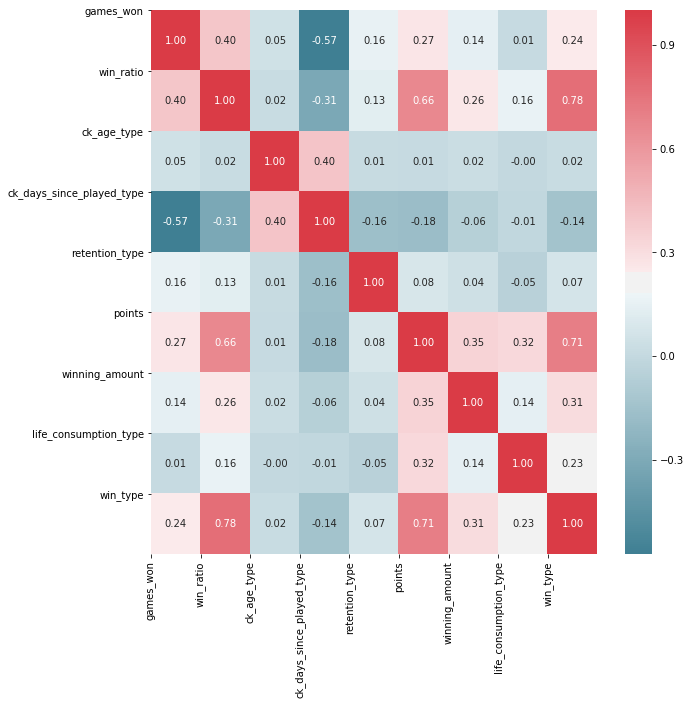

In [14]:
corr = data_result_final.corr()
#Plot figsize
fig, ax = plt.subplots(figsize=(10, 10))
#Generate Color Map, red & blue
colormap = sns.diverging_palette(220, 10, as_cmap=True)
#Generate Heat Map, allow annotations and place floats in map
sns.heatmap(corr, cmap=colormap, annot=True, fmt=".2f")
#Apply xticks
plt.xticks(range(len(corr.columns)), corr.columns);
#Apply yticks
plt.yticks(range(len(corr.columns)), corr.columns)
#show plot
plt.show()

In [15]:
data_results_final_with_dummies = pd.get_dummies(data_result_final, columns=['ck_age_type','ck_days_since_played_type','life_consumption_type','win_type'])


In [16]:
data_results_final_with_dummies.head(10)

,games_won,win_ratio,retention_type,points,winning_amount,ck_age_type_1,ck_age_type_2,ck_age_type_3,ck_days_since_played_type_1,ck_days_since_played_type_2,ck_days_since_played_type_3,life_consumption_type_0,life_consumption_type_1,win_type_0,win_type_1
user_id,,,,,,,,,,,,,,,
33138,0,0.0,0,13200,0.00,1,0,0,1,0,0,1,0,1,0
82870,1,1.0,0,17250,0.23,1,0,0,1,0,0,0,1,0,1
94260,1,1.0,0,16470,0.11,1,0,0,1,0,0,0,1,0,1
194772,0,0.0,0,7110,0.00,1,0,0,1,0,0,1,0,1,0
314248,1,1.0,0,20010,0.44,1,0,0,1,0,0,1,0,0,1
1037509,0,0.0,0,6450,0.00,1,0,0,1,0,0,1,0,1,0
1618800,0,0.0,0,10200,0.00,1,0,0,1,0,0,0,1,1,0
1641440,0,0.0,0,3610,0.00,1,0,0,1,0,0,1,0,1,0
1847646,0,0.0,0,6200,0.00,1,0,0,1,0,0,1,0,1,0


In [17]:
from sklearn import preprocessing
plt.rc("font", size=14)
from sklearn.linear_model import LogisticRegression
#from sklearn.cross_validation import train_test_split
from sklearn.model_selection import train_test_split
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)

In [18]:
X = data_results_final_with_dummies.loc[:, data_results_final_with_dummies.columns != 'retention_type']
y = data_results_final_with_dummies.loc[:, data_results_final_with_dummies.columns == 'retention_type']

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [20]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

/Users/snehit/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/Users/snehit/anaconda3/lib/python3.7/site-packages/sklearn/utils/validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='warn',
          n_jobs=None, penalty='l2', random_state=None, solver='warn',
          tol=0.0001, verbose=0, warm_start=False)

In [21]:
y_pred = logreg.predict(X_test)

In [22]:
#print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(X_test, y_test)))
print("Accuracy: {:.2f}".format(metrics.accuracy_score(y_test, y_pred)))
print("Precision: {:.2f}".format(metrics.precision_score(y_test, y_pred)))
print("Recall: {:.2f}".format(metrics.recall_score(y_test, y_pred)))

Accuracy: 0.77
Precision: 0.77
Recall: 1.00


In [23]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     61510
           1       0.77      1.00      0.87    202953

   micro avg       0.77      0.77      0.77    264463
   macro avg       0.38      0.50      0.43    264463
weighted avg       0.59      0.77      0.67    264463



/Users/snehit/anaconda3/lib/python3.7/site-packages/sklearn/metrics/classification.py:1143: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
/Users/snehit/anaconda3/lib/python3.7/site-packages/sklearn/metrics/classification.py:1143: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
/Users/snehit/anaconda3/lib/python3.7/site-packages/sklearn/metrics/classification.py:1143: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)


In [24]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.767415479670124

In [25]:
y_pred_train = logreg.predict(X_train)
accuracy_score(y_train,y_pred_train)

0.766342342459138

In [26]:
metrics.precision_score(y_test, y_pred)

0.767415479670124